# Grover's Algorithm: Amplitude Damping Simulation

**Section A** — PennyLane `default.mixed` validation at small $N \in \{4, 8, 16, 32\}$.
**Section B** — Analytic large-$N$ sweep ($N$ up to 8192).

$$P(k, N, \gamma) = (1-\gamma)^{n\cdot(2k+1)}\cdot\sin^2\!\bigl((2k+1)\theta\bigr), \qquad \theta = \arcsin\!\left(\tfrac{1}{\sqrt{N}}\right)$$

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

sys.path.insert(0, os.path.abspath('../src'))

from noise.amplitude_damping import gamma_from_specs
from noise.analytic_noisy import noisy_success_probability
from grover.grover import optimal_iterations

FIGURES_DIR = '../results/figures'
RESULTS_DIR = '../data/results'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

/Users/devinlucas/Desktop/CS480A8/CS480A8-Final-Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Hardware Parameters

In [2]:
hw = pd.read_csv('../data/hardware_specs/hardware_specs.csv')
hw['ratio'] = hw['T1_us'] * 1000 / hw['t_gate_ns']
hw['gamma'] = hw.apply(lambda r: gamma_from_specs(r['T1_us'], r['t_gate_ns']), axis=1)
platforms = hw['platform'].tolist()
display(hw[['platform', 'T1_us', 't_gate_ns', 'ratio', 'gamma']])

,platform,T1_us,t_gate_ns,ratio,gamma
0,IBM Quantum (Eagle),100,50,2000.000000,0.000500
1,Google Quantum AI (Sycamore),15,12,1250.000000,0.000800
2,Intel Tunnel Falls (spin),1000,1000,1000.000000,0.001000
3,IonQ Aria (trapped ion),10000000,135000,74074.074074,0.000013


## Noisy Grover Circuit (`default.mixed`)

In [3]:
def make_noisy_circuit(n_qubits, gamma):
    dev = qml.device('default.mixed', wires=n_qubits)

    @qml.qnode(dev)
    def circuit(k):
        for w in range(n_qubits):
            qml.Hadamard(wires=w)
        for w in range(n_qubits):
            qml.AmplitudeDamping(gamma, wires=w)
        for _ in range(k):
            qml.FlipSign(0, wires=range(n_qubits))
            for w in range(n_qubits):
                qml.AmplitudeDamping(gamma, wires=w)
            qml.GroverOperator(wires=range(n_qubits))
            for w in range(n_qubits):
                qml.AmplitudeDamping(gamma, wires=w)
        return qml.probs(wires=range(n_qubits))

    return circuit

## Section A — PennyLane Validation (Small N)

Sweeps $N \in \{4, 8, 16, 32\}$ on all platforms; records both PennyLane and analytic results.
`k_max = k_opt + 2` keeps total runtime under one minute.

In [4]:
N_values_small = [4, 8, 16, 32]
sweep = {}

for _, row in hw.iterrows():
    platform = row['platform']
    gamma = row['gamma']
    sweep[platform] = {}
    for N in N_values_small:
        n_qubits = int(np.log2(N))
        k_opt = optimal_iterations(N)
        k_max = k_opt + 2
        circuit = make_noisy_circuit(n_qubits, gamma)
        ks, probs_pl, probs_an = [], [], []
        for k in range(k_max + 1):
            p_pl = float(circuit(k)[0])
            p_an = noisy_success_probability(N, k, gamma)
            ks.append(k)
            probs_pl.append(p_pl)
            probs_an.append(p_an)
        sweep[platform][N] = {'k_opt': k_opt, 'ks': ks, 'probs_pl': probs_pl, 'probs_an': probs_an}
        print(f'  {platform}  N={N}  k_opt={k_opt}  P_pl={probs_pl[k_opt]:.4f}  P_an={probs_an[k_opt]:.4f}')
    print()

  IBM Quantum (Eagle)  N=4  k_opt=1  P_pl=0.9993  P_an=0.9970
  IBM Quantum (Eagle)  N=8  k_opt=2  P_pl=0.9438  P_an=0.9382


  IBM Quantum (Eagle)  N=16  k_opt=3  P_pl=0.9589  P_an=0.9480


  IBM Quantum (Eagle)  N=32  k_opt=4  P_pl=0.9955  P_an=0.9770

  Google Quantum AI (Sycamore)  N=4  k_opt=1  P_pl=0.9988  P_an=0.9952
  Google Quantum AI (Sycamore)  N=8  k_opt=2  P_pl=0.9430  P_an=0.9340


  Google Quantum AI (Sycamore)  N=16  k_opt=3  P_pl=0.9575  P_an=0.9400


  Google Quantum AI (Sycamore)  N=32  k_opt=4  P_pl=0.9932  P_an=0.9639

  Intel Tunnel Falls (spin)  N=4  k_opt=1  P_pl=0.9985  P_an=0.9940
  Intel Tunnel Falls (spin)  N=8  k_opt=2  P_pl=0.9424  P_an=0.9312


  Intel Tunnel Falls (spin)  N=16  k_opt=3  P_pl=0.9566  P_an=0.9348


  Intel Tunnel Falls (spin)  N=32  k_opt=4  P_pl=0.9918  P_an=0.9552

  IonQ Aria (trapped ion)  N=4  k_opt=1  P_pl=1.0000  P_an=0.9999
  IonQ Aria (trapped ion)  N=8  k_opt=2  P_pl=0.9453  P_an=0.9451


  IonQ Aria (trapped ion)  N=16  k_opt=3  P_pl=0.9613  P_an=0.9610


  IonQ Aria (trapped ion)  N=32  k_opt=4  P_pl=0.9991  P_an=0.9986



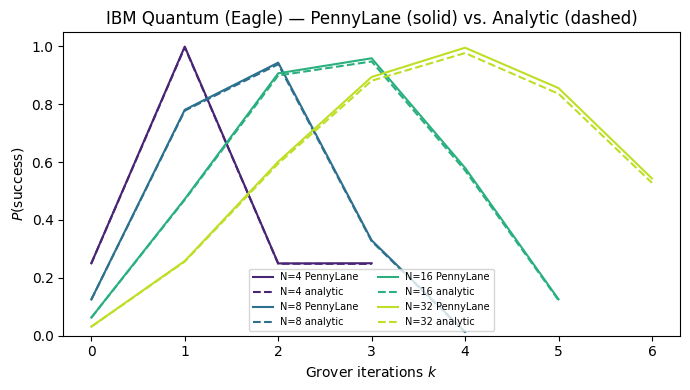

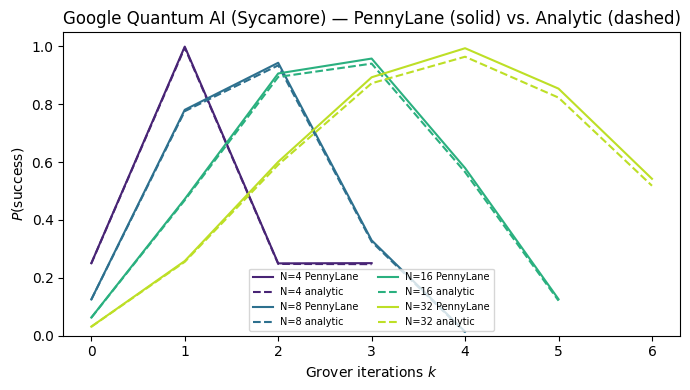

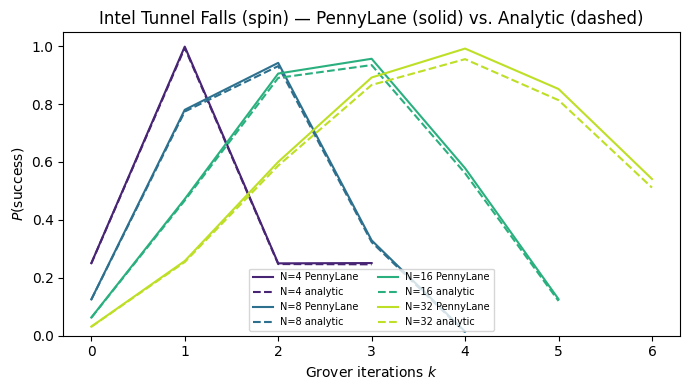

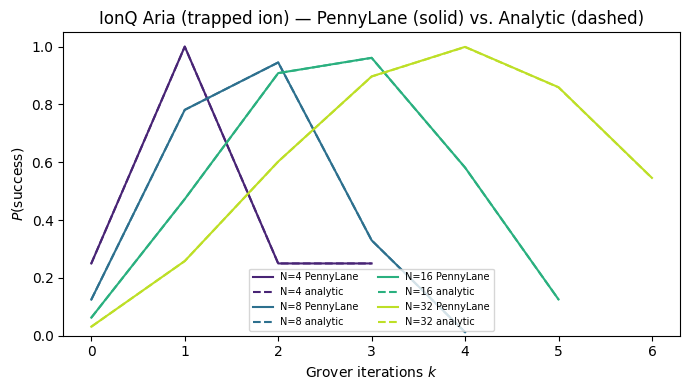

In [5]:
colors_n = {N: c for N, c in zip(N_values_small, plt.cm.viridis(np.linspace(0.1, 0.9, len(N_values_small))))}

for platform in platforms:
    fig, ax = plt.subplots(figsize=(7, 4))
    for N in N_values_small:
        r = sweep[platform][N]
        color = colors_n[N]
        ax.plot(r['ks'], r['probs_pl'], color=color, label=f'N={N} PennyLane')
        ax.plot(r['ks'], r['probs_an'], color=color, linestyle='--', label=f'N={N} analytic')
    ax.set_xlabel('Grover iterations $k$')
    ax.set_ylabel('$P(\mathrm{success})$')
    ax.set_title(f'{platform} — PennyLane (solid) vs. Analytic (dashed)')
    ax.legend(fontsize=7, ncol=2)
    ax.set_ylim(0, None)
    safe = platform.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/validation_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [6]:
max_dev = 0.0
for platform in platforms:
    for N in N_values_small:
        r = sweep[platform][N]
        for p_pl, p_an in zip(r['probs_pl'], r['probs_an']):
            max_dev = max(max_dev, abs(p_pl - p_an))
print(f'Max absolute deviation (PennyLane vs. analytic): {max_dev:.2e}')

Max absolute deviation (PennyLane vs. analytic): 3.85e-02


## Section B — Analytic Large-N Sweep

Analytic model only; $N \in \{4, 8, 16, 32, 64, 128, 256, 1024, 4096, 8192\}$.
Threshold depth: first $k$ where $P < 1/N$; `inf` if never reached within sweep range.

In [7]:
N_values_large = [4, 8, 16, 32, 64, 128, 256, 1024, 4096, 8192]
analytic_sweep = {}

for _, row in hw.iterrows():
    platform = row['platform']
    gamma = row['gamma']
    analytic_sweep[platform] = {}
    for N in N_values_large:
        k_opt = optimal_iterations(N)
        k_max = max(2 * k_opt, k_opt + 20)
        ks = list(range(k_max + 1))
        probs = [noisy_success_probability(N, k, gamma) for k in ks]
        analytic_sweep[platform][N] = {'k_opt': k_opt, 'ks': ks, 'probs': probs}

In [8]:
records = []
for _, row in hw.iterrows():
    platform = row['platform']
    for N in N_values_large:
        r = analytic_sweep[platform][N]
        classical = 1.0 / N
        # skip k=0: analytic formula gives P(0) = (1-gamma)^n/N < 1/N for any gamma>0,
        # so searching from k=1 correctly finds the depth where quantum advantage is lost
        threshold_depth = next(
            (k for k, p in zip(r['ks'], r['probs']) if k >= 1 and p < classical),
            float('inf'),
        )
        best_success = r['probs'][r['k_opt']]
        records.append({
            'platform': platform,
            'N': N,
            'threshold_depth': threshold_depth,
            'best_success': best_success,
            'T1_us': row['T1_us'],
            't_gate_ns': row['t_gate_ns'],
            'ratio': row['ratio'],
        })

thresholds = pd.DataFrame(records)
thresholds.to_csv(f'{RESULTS_DIR}/thresholds.csv', index=False)

inf_cases = thresholds[np.isinf(thresholds['threshold_depth'])]
if not inf_cases.empty:
    print('Platforms where P never drops below 1/N within sweep range:')
    print(inf_cases[['platform', 'N', 'threshold_depth']].to_string(index=False))
    print()
print(thresholds.to_string(index=False))

                    platform    N  threshold_depth  best_success    T1_us  t_gate_ns        ratio
         IBM Quantum (Eagle)    4                2      0.997004      100         50  2000.000000
         IBM Quantum (Eagle)    8                4      0.938249      100         50  2000.000000
         IBM Quantum (Eagle)   16                6      0.947954      100         50  2000.000000
         IBM Quantum (Eagle)   32                8      0.976952      100         50  2000.000000
         IBM Quantum (Eagle)   64               12      0.958467      100         50  2000.000000
         IBM Quantum (Eagle)  128               17      0.938108      100         50  2000.000000
         IBM Quantum (Eagle)  256               25      0.904789      100         50  2000.000000
         IBM Quantum (Eagle) 1024               50      0.774499      100         50  2000.000000
         IBM Quantum (Eagle) 4096              100      0.545499      100         50  2000.000000
         IBM Quantum

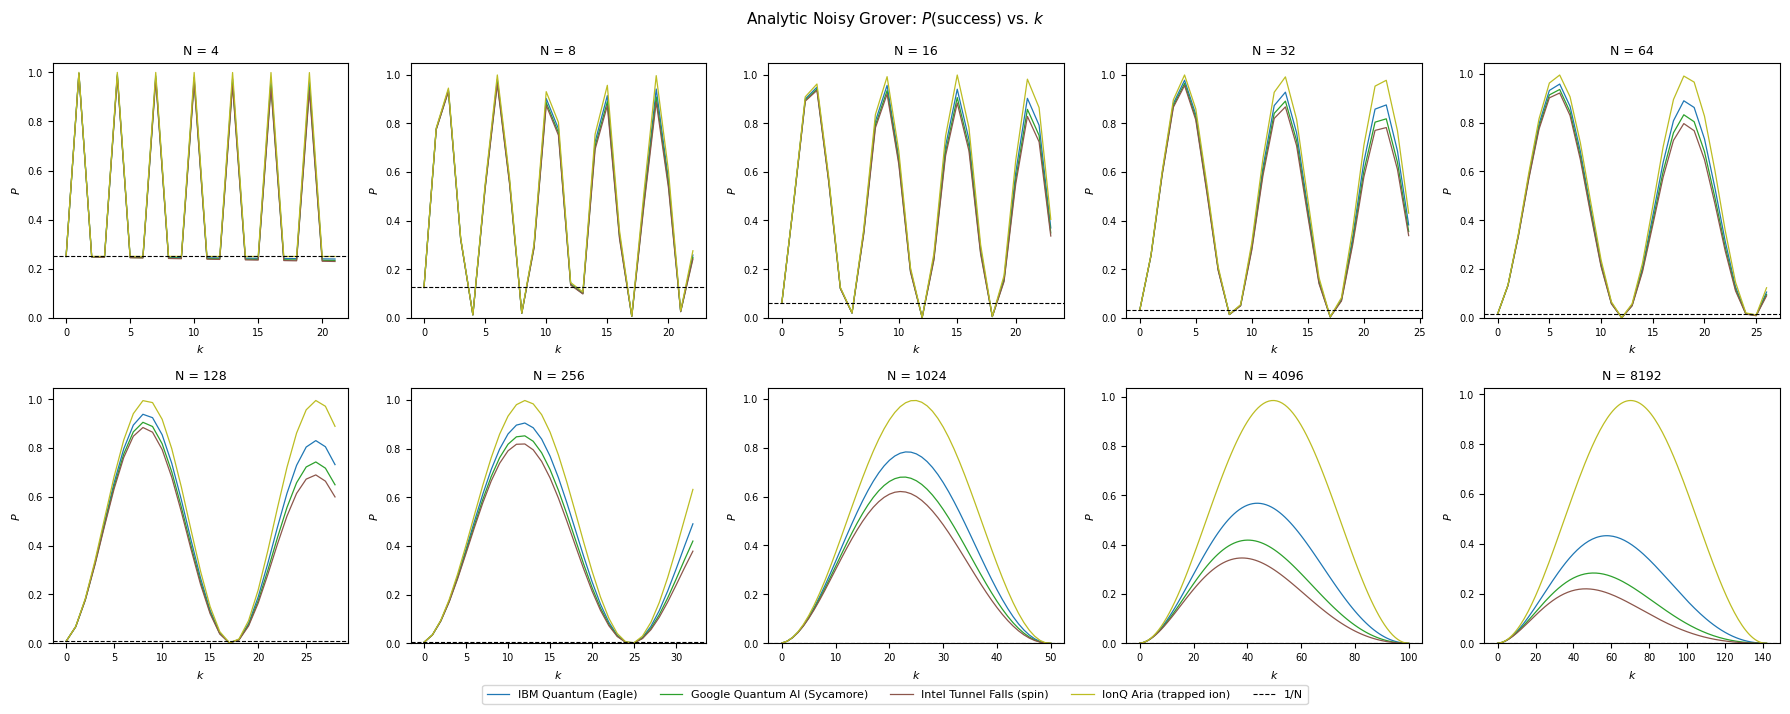

In [9]:
colors_p = {p: c for p, c in zip(platforms, plt.cm.tab10(np.linspace(0, 0.8, len(platforms))))}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, N in zip(axes.flat, N_values_large):
    classical = 1.0 / N
    for platform in platforms:
        r = analytic_sweep[platform][N]
        ax.plot(r['ks'], r['probs'], label=platform, color=colors_p[platform], linewidth=0.9)
    ax.axhline(classical, color='black', linestyle='--', linewidth=0.8, label='1/N')
    ax.set_title(f'N = {N}', fontsize=9)
    ax.set_xlabel('$k$', fontsize=8)
    ax.set_ylabel('$P$', fontsize=8)
    ax.set_ylim(0, None)
    ax.tick_params(labelsize=7)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle(r'Analytic Noisy Grover: $P(\mathrm{success})$ vs. $k$', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/analytic_sweep_grid.png', dpi=150, bbox_inches='tight')
plt.show()

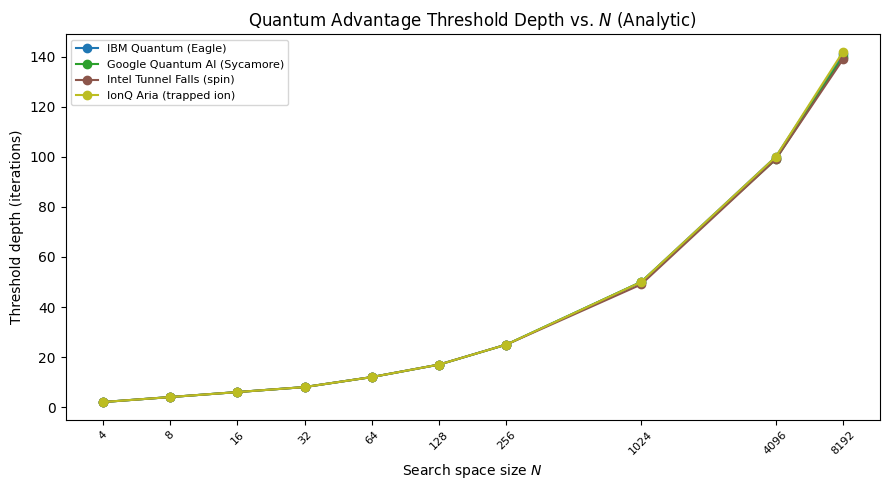

In [10]:
fig2, ax2 = plt.subplots(figsize=(9, 5))
for platform in platforms:
    sub = thresholds[thresholds['platform'] == platform].sort_values('N')
    finite_sub = sub[~np.isinf(sub['threshold_depth'])]
    if not finite_sub.empty:
        ax2.plot(finite_sub['N'], finite_sub['threshold_depth'],
                 marker='o', label=platform, color=colors_p[platform])

ax2.set_xlabel('Search space size $N$')
ax2.set_ylabel('Threshold depth (iterations)')
ax2.set_title('Quantum Advantage Threshold Depth vs. $N$ (Analytic)')
ax2.set_xscale('log', base=2)
ax2.set_xticks(N_values_large)
ax2.set_xticklabels([str(N) for N in N_values_large], rotation=45, fontsize=8)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/analytic_threshold_vs_N.png', dpi=150)
plt.show()